<a href="https://colab.research.google.com/github/khadija2027/Medical-image-classification-using-QCNN/blob/main/Dental%20disease%20classification/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Load the data

In [34]:
from google.colab import drive
drive.mount('/content/drive')

import os

# Change this to wherever you put/unzipped the dataset in your Drive
DATA_DIR = '/content/drive/MyDrive/Research_intership_khadija_ELMRABET/Deliverables/Codes/Dental disease classification/Dental OPG (Classification)'

for root, dirs, files in os.walk(DATA_DIR):
    level = root.replace(DATA_DIR, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dental OPG (Classification)/
  BDC-BDR/
  Impacted teeth/
  Infection/
  Caries/
  Fractured Teeth/
  Healthy Teeth/


Label frequency

/tmp/ipykernel_619/2001865997.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, y='label', order=order, palette='viridis')


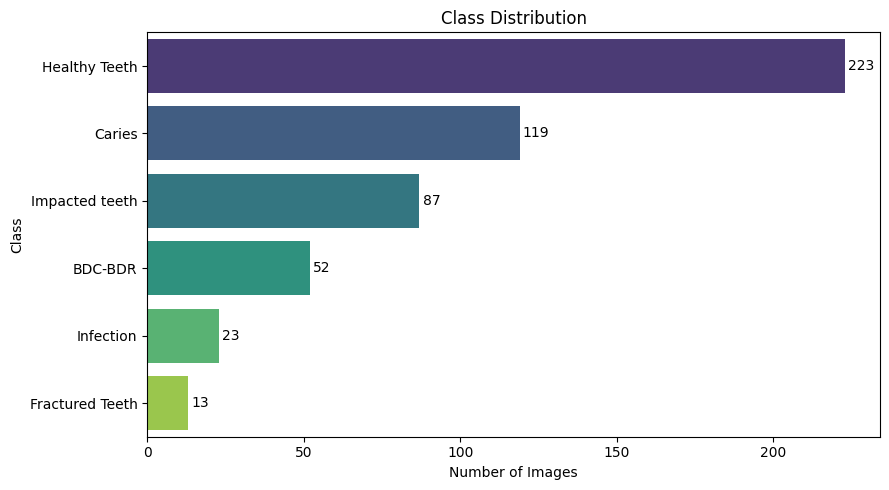

In [35]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

records = []
for class_dir in Path(DATA_DIR).iterdir():
    if class_dir.is_dir():
        for img_path in class_dir.rglob('*'):
            if img_path.suffix.lower() in {'.jpg'}:
                records.append({'filepath': str(img_path), 'label': class_dir.name})

df = pd.DataFrame(records)
plt.figure(figsize=(9,5))
order = df['label'].value_counts().index
ax = sns.countplot(data=df, y='label', order=order, palette='viridis')
plt.title('Class Distribution')
plt.xlabel('Number of Images')
plt.ylabel('Class')

for i, v in enumerate(df['label'].value_counts()[order].values):
    ax.text(v + 1, i, str(v), va='center')

plt.tight_layout()
plt.show()

Image dimension

Image dimension stats:
             width       height
count   517.000000   517.000000
mean   1205.874275   610.847195
std     262.791318   143.214812
min     497.000000   259.000000
25%    1058.000000   511.000000
50%    1176.000000   593.000000
75%    1298.000000   678.000000
max    1988.000000  1260.000000

Color modes: mode
L      474
RGB     43
Name: count, dtype: int64

Corrupted/unreadable images: 0


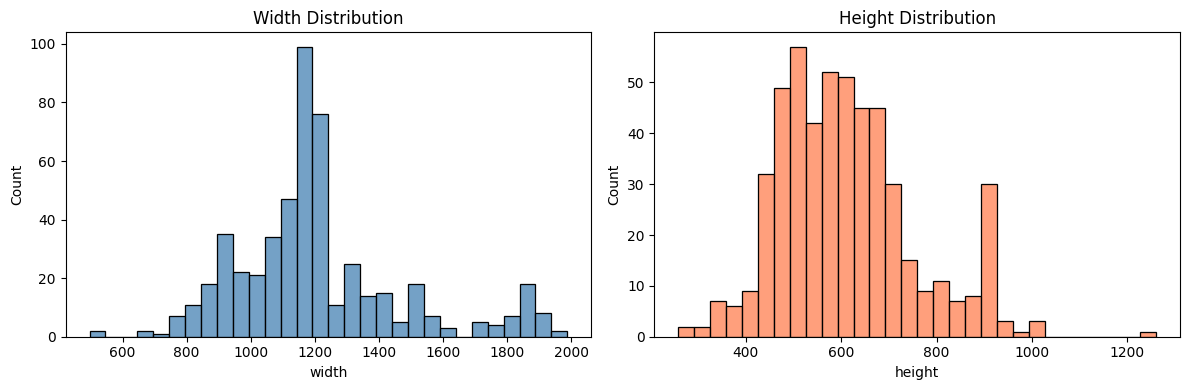

In [37]:
img_info = []
for path in df['filepath']:
    try:
        with Image.open(path) as img:
            img_info.append({
                'filepath': path,
                'width': img.width,
                'height': img.height,
                'mode': img.mode,
                'aspect_ratio': round(img.width / img.height, 2)
            })
    except Exception as e:
        img_info.append({'filepath': path, 'width': None, 'height': None, 'mode': None, 'aspect_ratio': None})

img_df = pd.DataFrame(img_info)
df = df.merge(img_df, on='filepath')

print("Image dimension stats:")
print(df[['width', 'height']].describe())
print("\nColor modes:", df['mode'].value_counts())
print("\nCorrupted/unreadable images:", df['width'].isna().sum())
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['width'], bins=30, ax=axes[0], color='steelblue')
axes[0].set_title('Width Distribution')
sns.histplot(df['height'], bins=30, ax=axes[1], color='coral')
axes[1].set_title('Height Distribution')
plt.tight_layout()
plt.show()

Display a subset of images from each class

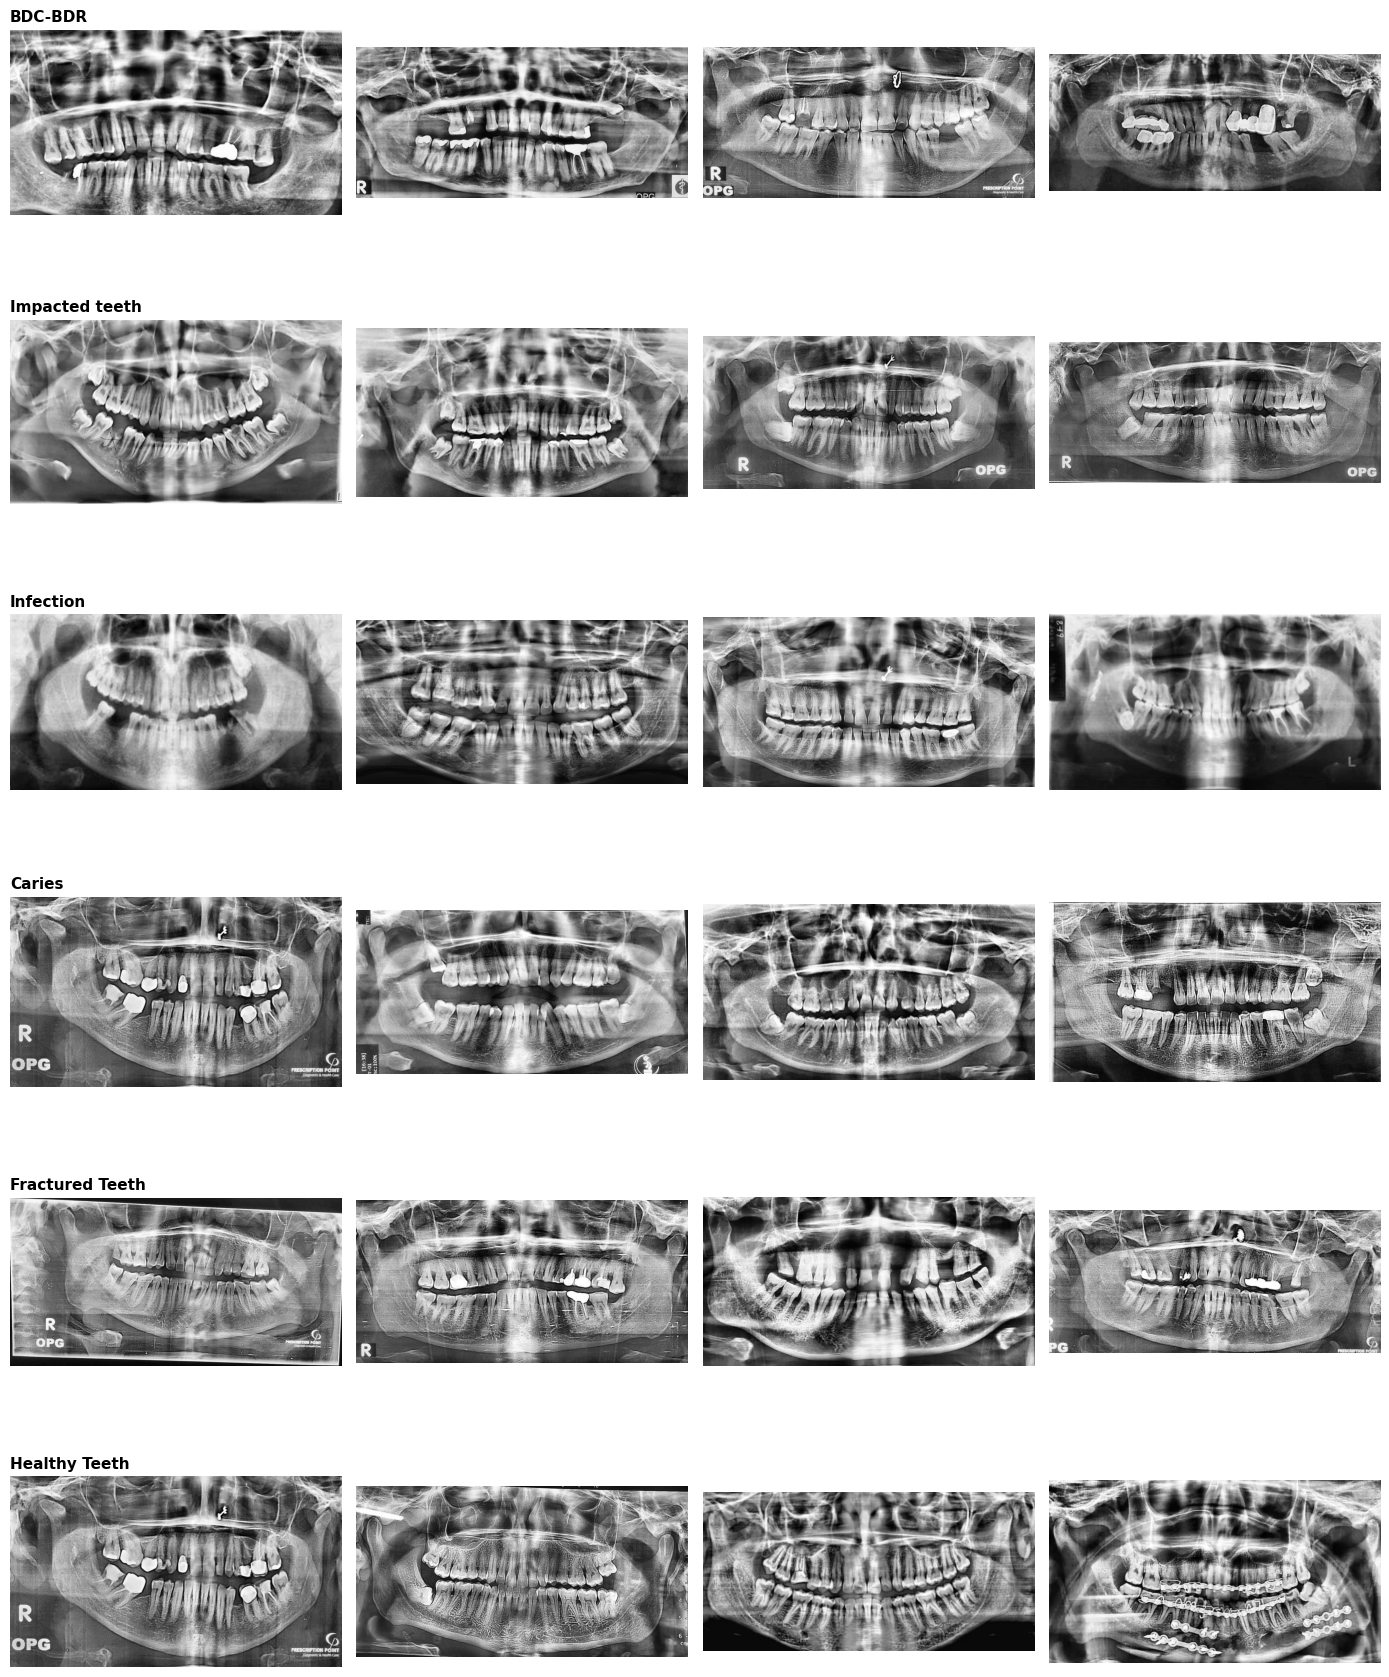

In [36]:
from PIL import Image
import numpy as np

classes = df['label'].unique()
fig, axes = plt.subplots(len(classes), 4, figsize=(14, 3*len(classes)))

for i, cls in enumerate(classes):
    sample_paths = df[df['label'] == cls]['filepath'].sample(min(4, len(df[df['label']==cls])), random_state=42)
    for j, path in enumerate(sample_paths):
        img = Image.open(path)
        if img.mode == 'L':
            axes[i, j].imshow(img, cmap='gray')
        else:
            axes[i, j].imshow(img)
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_ylabel(cls, fontsize=10)
    axes[i, 0].set_title(cls, loc='left', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

Some images are duplicated across multiple classes (e.g., Caries and Healthy), indicating that this is a multi-label classification problem, where a single image can contain multiple dental conditions as well as healthy teeth.

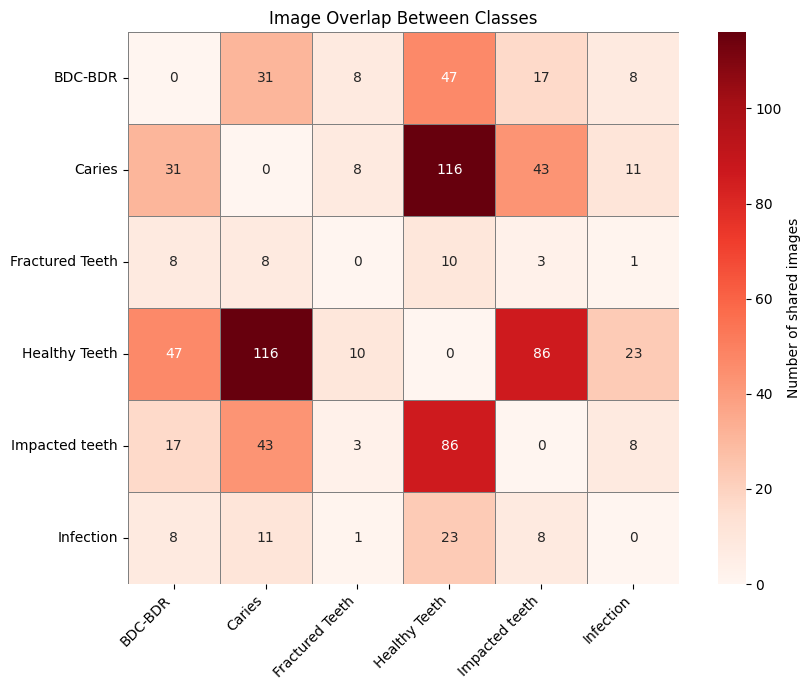

In [44]:
import hashlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def get_file_hash(filepath):
    try:
        with open(filepath, 'rb') as f:
            return hashlib.md5(f.read()).hexdigest()
    except:
        return None

if 'file_hash' not in df.columns:
    df['file_hash'] = df['filepath'].apply(get_file_hash)

classes = sorted(df['label'].unique())
n = len(classes)

# Build a dict: class -> set of hashes belonging to it
class_hashes = {cls: set(df[df['label'] == cls]['file_hash']) for cls in classes}

# Overlap matrix: entry (i,j) = number of unique images appearing in BOTH class i and class j
overlap_matrix = np.zeros((n, n), dtype=int)

for i, cls_i in enumerate(classes):
    for j, cls_j in enumerate(classes):
        if i == j:
            overlap_matrix[i, j] = len(class_hashes[cls_i])  # diagonal = class size
        else:
            overlap_matrix[i, j] = len(class_hashes[cls_i] & class_hashes[cls_j])

overlap_df = pd.DataFrame(overlap_matrix, index=classes, columns=classes)
overlap_no_diag = overlap_df.copy()
np.fill_diagonal(overlap_no_diag.values, 0)

plt.figure(figsize=(9, 7))
sns.heatmap(
    overlap_no_diag,
    annot=True,
    fmt='d',
    cmap='Reds',
    linewidths=0.5,
    linecolor='gray',
    square=True,
    cbar_kws={'label': 'Number of shared images'}
)
plt.title('Image Overlap Between Classes', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Build multi-label table and keep healthy as all-zero rows

In [39]:
df['filename'] = df['filepath'].apply(lambda p: Path(p).name)
grouped_labels = df.groupby('filename')['label'].apply(set)
canonical_path = df.groupby('filename')['filepath'].first()

# All classes, excluding Healthy Teeth from the label columns
all_classes = sorted(df['label'].unique())
disease_classes = [c for c in all_classes if c != 'Healthy Teeth']

# Build multi-hot dataframe
multi_label_df = pd.DataFrame(0, index=grouped_labels.index, columns=disease_classes)

for fname, labels in grouped_labels.items():
    for cls in labels:
        if cls in disease_classes:
            multi_label_df.loc[fname, cls] = 1

multi_label_df['filepath'] = canonical_path
multi_label_df = multi_label_df.reset_index().rename(columns={'filename': 'image_name'})

# Reorder columns: image_name, filepath, then disease columns
multi_label_df = multi_label_df[['image_name', 'filepath'] + disease_classes]

multi_label_df.head()

,image_name,filepath,BDC-BDR,Caries,Fractured Teeth,Impacted teeth,Infection
0,1.jpg,/content/drive/MyDrive/Research_intership_khad...,0,1,0,0,1
1,10.jpg,/content/drive/MyDrive/Research_intership_khad...,0,1,0,1,0
2,100.jpg,/content/drive/MyDrive/Research_intership_khad...,0,1,0,0,0
3,101.jpg,/content/drive/MyDrive/Research_intership_khad...,1,1,0,0,0
4,102.jpg,/content/drive/MyDrive/Research_intership_khad...,0,0,0,1,0


Visualize the label cardinality: how many labels per image

Total images: 231
Number of disease classes: 5


/tmp/ipykernel_619/1068510496.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='num_labels', data=multi_label_df, palette='mako')


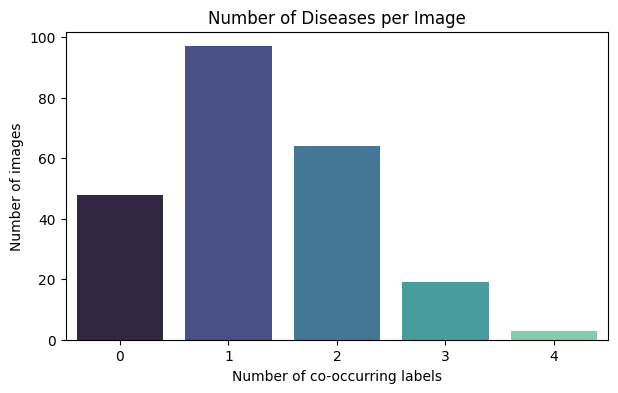

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

disease_classes = [c for c in multi_label_df.columns if c not in ['image_name', 'filepath']]
print(f"Total images: {len(multi_label_df)}")
print(f"Number of disease classes: {len(disease_classes)}")

multi_label_df['num_labels'] = multi_label_df[disease_classes].sum(axis=1)

plt.figure(figsize=(7, 4))
sns.countplot(x='num_labels', data=multi_label_df, palette='mako')
plt.title('Number of Diseases per Image')
plt.xlabel('Number of co-occurring labels')
plt.ylabel('Number of images')
plt.show()


Label correlation

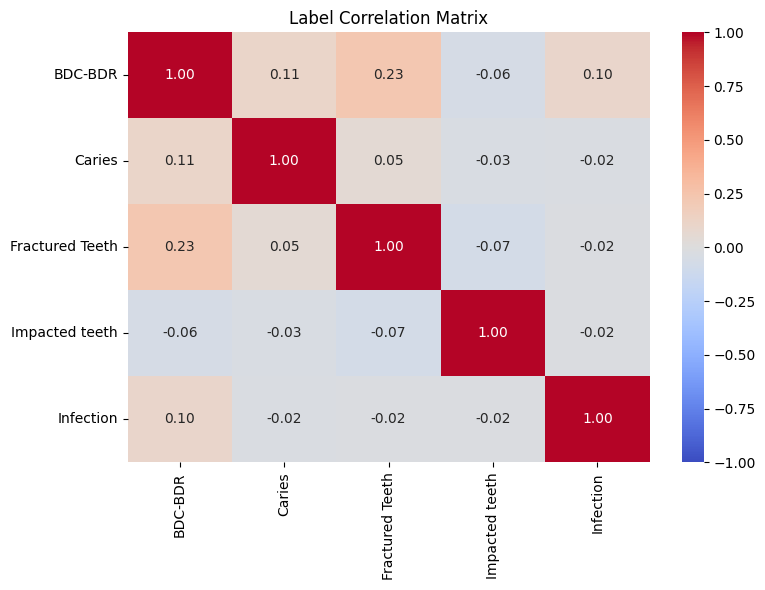

In [41]:
plt.figure(figsize=(8, 6))
sns.heatmap(multi_label_df[disease_classes].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Label Correlation Matrix')
plt.tight_layout()
plt.show()

Save the dataset as a CSV file for use in the preprocessing and training notebooks

In [43]:
save_path = '/content/drive/MyDrive/Research_intership_khadija_ELMRABET/Deliverables/Codes/Dental disease classification/multi_label_df.csv'
multi_label_df.to_csv(save_path, index=False)
print(f"Saved to: {save_path}")

Saved to: /content/drive/MyDrive/Research_intership_khadija_ELMRABET/Deliverables/Codes/Dental disease classification/multi_label_df.csv
